# Saving data from distance sensor into a CSV file

You can use that CSV file to do further analysis with your data at a later time. Will be very useful for your long assignment!


In [36]:
# import all the needed libraries 
from Arduino import Arduino
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

You need to update the version of the Arduino-Python3 library running on your Arduino.
The Arduino sketch is version
The Python installation is V0.6
Flash the prototype sketch again.
7878.2  μs
7874.8  μs
7885.8  μs
7876.2  μs
7874.6  μs
7888.6  μs
7883.0  μs
7912.6  μs
7085.0  μs
7895.4  μs
7902.8  μs
3484.6  μs
437.2  μs
257.6  μs
269.0  μs
247.6  μs
305.8  μs
274.2  μs
321.0  μs
525.8  μs
724.2  μs
917.8  μs
1012.2  μs
1012.4  μs
958.4  μs
832.2  μs
566.6  μs
357.6  μs
244.4  μs
200.8  μs
215.8  μs
337.4  μs
624.0  μs
816.6  μs
961.8  μs
1020.8  μs
997.2  μs
932.6  μs
723.6  μs
385.2  μs
231.0  μs
161.4  μs
247.6  μs
585.0  μs
850.8  μs
1090.2  μs
1094.6  μs
949.6  μs
663.8  μs
328.4  μs
145.0  μs
114.8  μs
234.2  μs
367.4  μs
717.4  μs
934.4  μs
1113.2  μs
1116.2  μs
929.2  μs
591.0  μs
332.4  μs
360.4  μs
219.6  μs
368.4  μs
815.6  μs
952.6  μs
1176.0  μs
1074.6  μs
924.4  μs
587.4  μs
314.6  μs
166.6  μs
181.6  μs
280.4  μs
540.4  μs
732.4  μs
906.2  μs
936.8  μs
846.4  μs
636.4 

Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 221, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 9] Bad file descriptor
Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 221, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 9] Bad file descriptor
Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/pytho

7895.8  μs


Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 194, in draw_text
    font.set_text(s, 0, flags=get_hinting_flag())
OSError: [Errno 9] Bad file descriptor
Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 194, in draw_text
    font.set_text(s, 0, flags=get_hinting_flag())
OSError: [Errno 9] Bad file descriptor
Exception ignored in: <_io.BufferedReader name='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/back

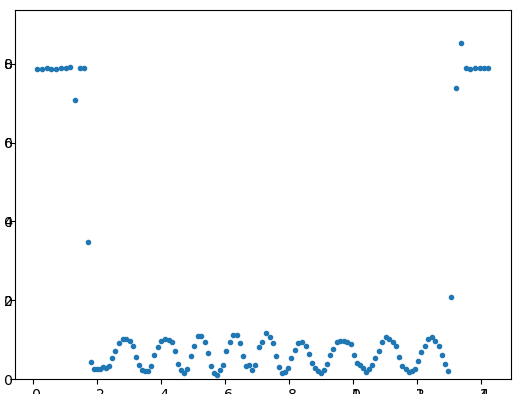

In [34]:
# PORT_NAME = 'COM5'                        # example of Windows port name
# PORT_NAME = '/dev/cu.usbmodem1101'      # example of Mac port name 
PIN_NUM = 2             # we decided to use digital pin 2 here to connect to the ultrasonic ranger, but feel free to use a different one

board = Arduino('9600') # find and connect microcontroller


# prepare our CSV file that will write our data to
timestr = time.strftime("%Y%m%d-%H%M%S")        # get current date and time into a string
FILE_NAME = 'distance_data_'+timestr+'.csv'     # define csv file name based on current data and time, so you don't lose track of when you took your data
data = np.array(['Counter', 'Time (s)', 'pulseTime (microseconds)'])    # first row of your data are column names

t = np.array([])     # initialize empty list for time data
y = np.array([])     # initialize empty list for ultrasound ranger output data

counter = 1     # to count how many data-points we have collected

startTime = time.time()     # capture current system time in seconds as a reference

try:
    while True:
        # this command returns the amount of time elapsed between the emitted sound pulse and the return echo 
        pulseTime = board.pulseIn_set(PIN_NUM, 'HIGH') # we decided to use digital pin 2 here, but feel free to use a different one

        # time at which data was collected from sensor
        time_stamp = time.time()-startTime 
        
        # write list of data to file
        new_data = np.array([counter, time_stamp, pulseTime])
        data = np.vstack([data, new_data])  # vstack is similar to np.append but adds the array as a new row instead
        
        # add new data to our lists
        t = np.append(t, time_stamp,)
        y = np.append(y, pulseTime) # MODFIY THIS!!!!!!!!!!!!!!! if you want to save the distance to object instead; what formula should you use?
        
        # print to console every 10 iterations, so as not to overwhelm your output cell. % is modulo operator
        # if counter % 10 == 0:
        print(pulseTime, ' μs')
            
        counter = counter + 1 # increment counter
        
        time.sleep(0.01) # delay to keep UART bus for getting overloaded

# the criteria to stop the above loop under the "try" statement is defined by the "except" statement here
# KeyboardInterrupt means Python is waiting for you to manually interrupt the program (using the "stop" button) or by pressing "i" twice in quick succession
except KeyboardInterrupt:

    # save your data to a CSV file
    df = pd.DataFrame(data)      # first convert our Numpy array into a Pandas dataframe (like a spreadsheet)
    df.to_csv(FILE_NAME, index=False, header=False)  # export that dataframe to a CSV file
    
    plt.figure()
    plt.plot(t, y, ".")  # plot data as points
    
    plt.xlabel("Time Stamp (s)")
    plt.ylabel("pulseTime (μs)")
    plt.ylim(0, 1.1*max(y))   # set y axis range
    
    board.close()   # close board connection

You should see that the data have been saved in a csv (comma separated value) file in the file explorer in the left pane. **You can open the file directly in JupyterLab, in Excel or load it back in a notebook with Python for further analysis (see below).**

# Importing CSV file using Python

This code will allow you to import data in CSV file you saved previously using the above code. Read the comments carefully, all the instructions are there.

In [2]:
# read the CSV file into a dataframe (i.e. like a Python spreadsheet)
df = pd.read_csv("distance_data_20250923-135048.csv")

# convert dataframe into a 2D Numpy array
a = df.to_numpy()

# the first column are the counters
counter_array = a[:,0]

# the second column are the time stamps
time_stamp_array = a[:,1]

# the third column are your measurements: either pulseTime or distance depending on how you modified the code above
measurement_array = a[:,2]


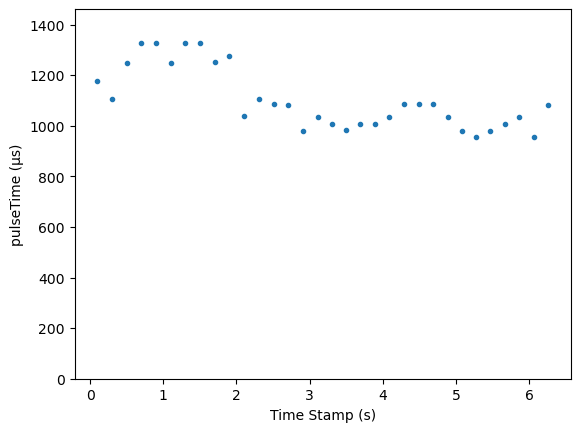

In [3]:
#to double-check everything was imported ok, plot the data again
plt.figure()
plt.plot(time_stamp_array, measurement_array,".")  # plot data as points
plt.xlabel("Time Stamp (s)")
plt.ylabel("pulseTime (μs)")
plt.ylim(0, 1.1*max(measurement_array));   # set y axis range

# Picking out data from a Numpy array

If you have superfluous data in a Numpy array, you can "pick" out the data you need using simple indexing and discard the rest. The easiest way to do this is:

1) Plot your data vs its index so you can identify the index of the start and end point you want to pick out. Note the counter array starts at 1 and the index of an array starts at 0.
2) Use the start and end index to pick out the data you need.
3) Plot again to see if you go the data you wanted. Otherwise go back to Step 2.

### Example

Say for example, I know that the data I want is between $2\,s$ and $6\,s$ (see graph above). Let's first determine what index $2\,s$ and $6\,s$ roughly correspond to.

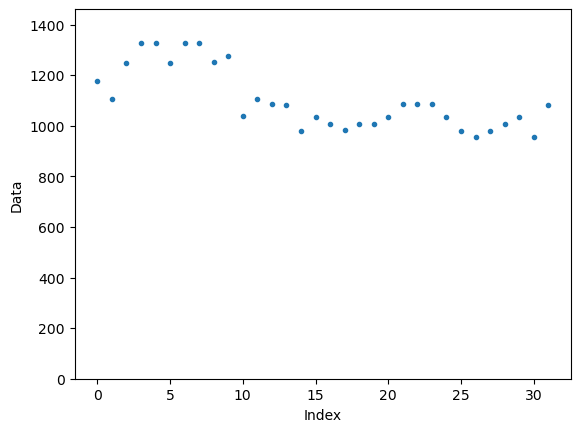

In [12]:
# Step 1
plt.figure()
plt.plot(counter_array-1, measurement_array,".")  # plot data as points
plt.xlabel("Index")
plt.ylabel("Data")
plt.ylim(0, 1.1*max(measurement_array));   # set y axis range

Seems like we need to remove everything before index 10 and after index 30. Let's do that:

In [9]:
# cropped time array
cropped_time_stamp_array = time_stamp_array[10:30]

# cropped measurement array
cropped_measurement_array = measurement_array[10:30]

Now, let's double-check that we picked out the data we wanted:

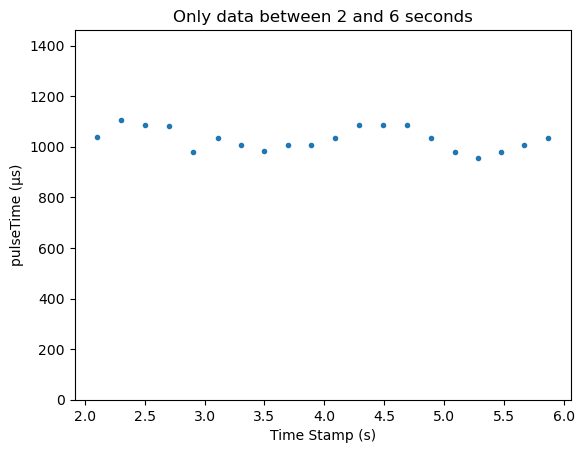

In [11]:
plt.figure()
plt.plot(cropped_time_stamp_array, cropped_measurement_array,".")  # plot data as points
plt.title("Only data between 2 and 6 seconds")
plt.xlabel("Time Stamp (s)")
plt.ylabel("pulseTime (μs)")
plt.ylim(0, 1.1*max(measurement_array));   # set y axis range